<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
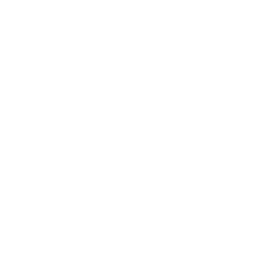
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Geenien yhteisekspressioverkon rakentaminen</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioteknologia / Genomiikkatutkimus &nbsp;|&nbsp; maaliskuu 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Tämä esimerkki käyttää **PROC CORR** -proseduuria rakentaakseen geenien yhteisekspressioverkon synteettisestä
RNA-seq-tyyppisestä ekspressiopaneelista. Paneeli sisältää **9 geeniä**, jotka on osoitettu kolmeen
toiminnalliseen moduuliin — *immuuni*, *solusykli* ja *metabolinen* (kolme geeniä kukin) —
mitattuina **100 kasvainnäytteen** yli. Spearmanin järjestyskorrelaatiota käytetään läpi analyysin,
koska ekspressiodata on tyypillisesti ei-normaalia ja sisältää poikkeavia havaintoja, joten järjestyspohjainen
kerroin on robustimpi kuin Pearson.

Analyysi palauttaa istutetun modulaarisen rakenteen suoraan datasta. Alla tuotettua
Spearman-matriisia lukien moduulien sisäinen keskikorrelaatio laskee **rho 0,67:sta immuunimoduulille**,
**0,36:een solusyklille** ja **0,17:een metaboliselle moduulille**, heijastaen
kuhunkin moduuliin suunniteltua laskevaa signaali-kohina-latausta. Moduulien väliset korrelaatiot
ovat keskimäärin olennaisesti nolla (keskimääräinen rho noin **-0,01**, keskimääräinen |rho| **0,07**), joten kolme
moduulia käyttäytyvät lähes riippumattomina yhteisekspressioyhteisöinä. Jokainen tässä lainattu luku on
luettu tämän muistikirjan PROC CORR -tulosteesta.

> **Huomautus mittakaavasta.** Tämä muistikirja ajetaan lisensoimattoman 100 havainnon rajan alla, joten
> otoskoko on 100 ja paneeli pidetään 9 geenissä — riittävän pieni, että täysi
> korrelaatiomatriisi, uudelleenmuotoiltu pariluettelo ja lämpökartta ovat kaikki täydellisiä ja tarkkoja,
> ilman katkaisua. Jokainen taulukko ja kuva heijastaa täsmälleen sitä, mitä laskettiin.

## Data

| Aineisto | Kuvaus | Rivit |
|---------|-------------|------|
| `WORK.EXPR` | Logaritmiasteikon ekspressio 9 geenille (3 moduulia x 3 geeniä) kasvainnäytteiden yli | 100 |

Generaattori arpoo kolme latenttia moduulisignaalia näytettä kohti. Kukin geeni latautuu oman
moduulinsa signaaliin plus riippumaton kohina, joten yhteisekspressio syntyy vain moduulin sisällä.
Immuunimoduuli käyttää suurinta signaalilatausta ja metabolinen moduuli pienintä, mikä
on gradientti, jonka korrelaatioanalyysin tulisi palauttaa.

---

In [1]:
/* --------------------------------------------------------
   Synteettinen ekspressiopaneeli: 9 geeniä, 3 moduulia, 100 näytettä
     imm1-imm3  immuuni      (vahva jaettu signaali)
     cyc1-cyc3  solusykli    (kohtalainen jaettu signaali)
     met1-met3  metabolinen  (heikko jaettu signaali)
   Kukin geeni = moduulin signaali + riippumaton geenitason kohina.
   -------------------------------------------------------- */
TIEDOT work.expr;
    CALL streaminit(42);
    TAULUKKO imm[3]; TAULUKKO cyc[3]; TAULUKKO met[3];
    TEE sample_id = 1 ASTI 100;
        s_imm = rand('normal', 0, 1.5);   /* immuunin latentti signaali     */
        s_cyc = rand('normal', 0, 1.2);   /* solusyklin latentti signaali   */
        s_met = rand('normal', 0, 1.0);   /* metabolinen latentti signaali  */
        TEE j = 1 ASTI 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        LOPPU;
        TEE j = 1 ASTI 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        LOPPU;
        TEE j = 1 ASTI 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        LOPPU;
        TULOSTE;
    LOPPU;
    SÄILYTÄ imm1-imm3 cyc1-cyc3 met1-met3;
SUORITA;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Geenikohtainen ekspressioyhteenveto (keskiarvo ja hajonta moduuleittain)
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.expr n mean std maxdec=3;
    MUUTTUJA imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    NIMIKE imm1="Immuunigeeni 1" imm2="Immuunigeeni 2" imm3="Immuunigeeni 3"
          cyc1="Solusykligeeni 1" cyc2="Solusykligeeni 2" cyc3="Solusykligeeni 3"
          met1="Metaboliageeni 1" met2="Metaboliageeni 2" met3="Metaboliageeni 3";
    OTSIKKO 'Geenien ekspressioyhteenveto (9 geenin paneeli, N=100)';
SUORITA;
OTSIKKO;

                                 Geenien ekspressioyhteenveto (9 geenin paneeli, N=100)                                 

                                                  The MEANS Procedure

 Variable  Label                    N        Mean     Std Dev
 ------------------------------------------------------------
 imm1      Immuunigeeni 1         100       6.042       1.125
 imm2      Immuunigeeni 2         100       5.925       1.122
 imm3      Immuunigeeni 3         100       5.863       1.273
 cyc1      Solusykligeeni 1       100       6.947       1.034
 cyc2      Solusykligeeni 2       100       7.003       1.002
 cyc3      Solusykligeeni 3       100       6.861       1.040
 met1      Metaboliageeni 1       100       5.144       0.940
 met2      Metaboliageeni 2       100       4.989       0.789
 met3      Metaboliageeni 3       100       5.015       0.979
 ------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Keskiarvot kasautuvat lähelle kunkin moduulin lähtötasoa (immuuni ~6, solusykli ~7, metabolinen ~5) ja
jokaisella geenillä on vertailukelpoinen hajonta, joten mikään yksittäinen geeni ei dominoi seuraavaa
korrelaatiorakennetta.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


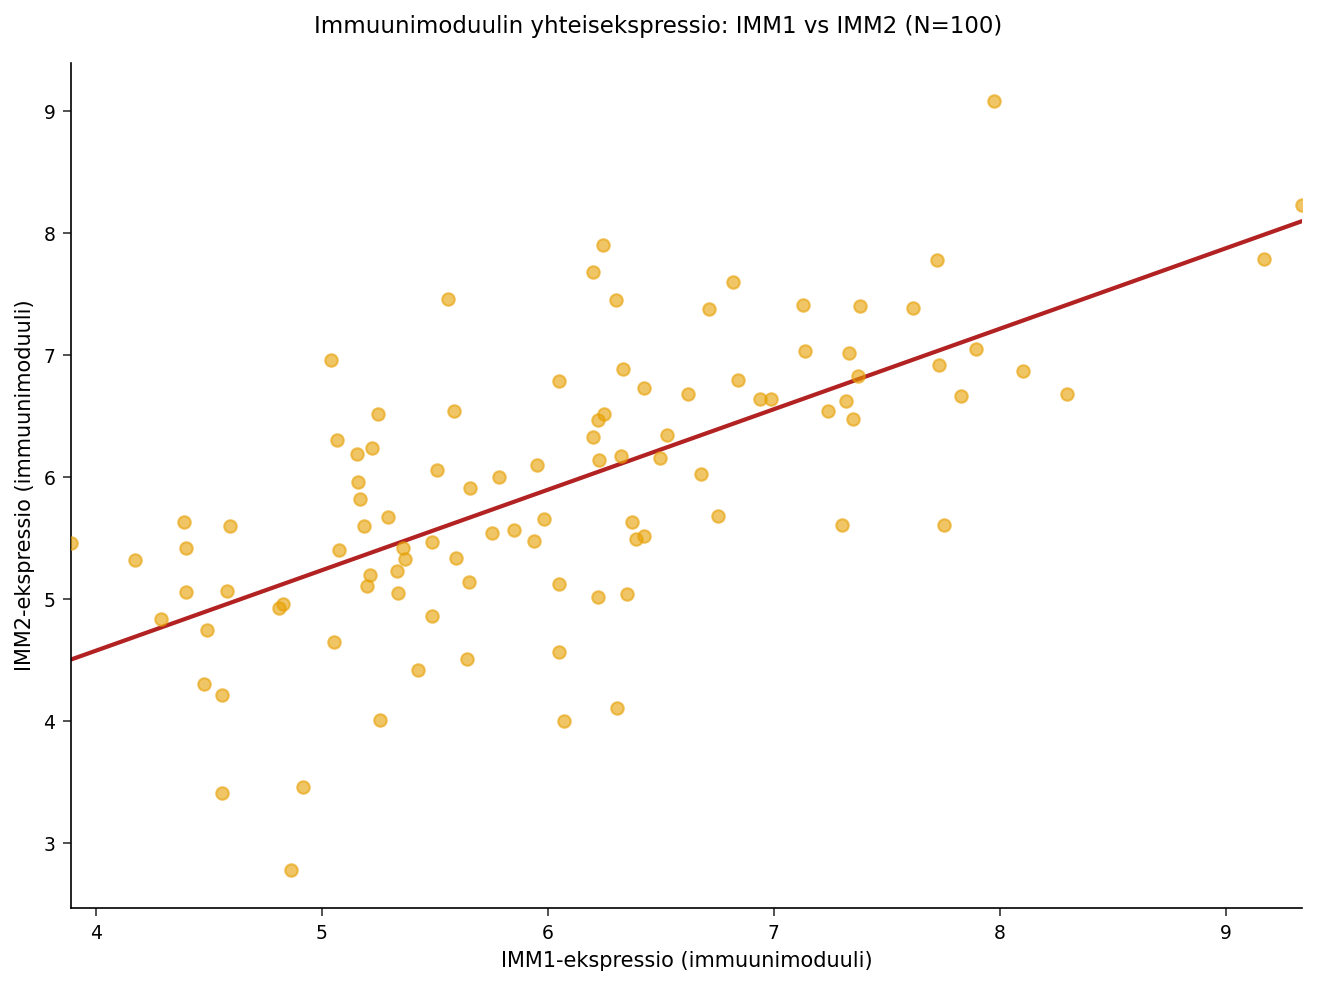

In [3]:
/* --------------------------------------------------------
   Kahden immuunimoduulin geenin hajontakuvio: visuaalinen tarkistus,
   että moduulin sisäinen yhteisekspressio on todellinen ja
   suunnilleen monotoninen
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS NIMIKE='IMM1-ekspressio (immuunimoduuli)';
    YAXIS NIMIKE='IMM2-ekspressio (immuunimoduuli)';
    OTSIKKO 'Immuunimoduulin yhteisekspressio: IMM1 vs IMM2 (N=100)';
SUORITA;
OTSIKKO;

Nouseva trendi vahvistaa, että kaksi immuunigeeniä nousevat ja laskevat yhdessä, mikä on visuaalinen
vastine niiden positiiviselle Spearman-korrelaatiolle alla olevassa matriisissa.

---

In [4]:
/* --------------------------------------------------------
   Spearman-korrelaatio kaikkien 9 geenin välillä
   nosimple vaimentaa yksinkertaisten tunnuslukujen lohkon;
   outs= kirjoittaa Spearman-matriisin verkkovaiheita varten
   -------------------------------------------------------- */
PROSEDUURI CORR TIEDOT=work.expr spearman nosimple
    outs=work.gene_corr;
    MUUTTUJA imm1-imm3 cyc1-cyc3 met1-met3;
    OTSIKKO 'Spearmanin korrelaatiomatriisi: 9 geenin yhteisekspressiopaneeli';
SUORITA;
OTSIKKO;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/8d219cca-72ea-48e9-88e6-2ac0ef5f23c1/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Lue matriisi kolmena lävistäjälohkona. **Immuuni**lohko (IMM1-IMM3) on tiiveimmin
yhteisekspressoitu (rho noin 0,63–0,72), **solusykli**lohko (CYC1-CYC3) on
kohtalainen (noin 0,29–0,41), ja **metabolinen** lohko (MET1-MET3) on heikoin (noin
0,13–0,25). Lohkon ulkopuoliset arvot — eri moduulien geeniparit — ovat lähellä
nollaa. Seuraava solu kvantifioi moduulin sisäisen ja moduulien välisen kontrastin, ja sen jälkeen tuleva lämpökartta
tekee lohkorakenteen näkyväksi.

---

In [5]:
/* --------------------------------------------------------
   Muotoile korrelaatiomatriisi (yksi rivi per geeni) pitkään
   muotoon (gene_x, gene_y, rho), merkiten kunkin parin moduulin
   sisäiseksi tai moduulien väliseksi. 9 geeniä -> 81 paririviä, joten
   mitään ei menetetä 100 havainnon rajan takia.
   -------------------------------------------------------- */
TIEDOT work.corr_long;
    ASETA work.gene_corr(MISSÄ=(_TYPE_='SCORR'));
    PITUUS gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    TAULUKKO g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    TAULUKKO gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    TEE k = 1 ASTI 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        TULOSTE;
    LOPPU;
    SÄILYTÄ gene_x gene_y rho mod_x mod_y same_module;
SUORITA;

/* --------------------------------------------------------
   Moduulin sisäinen vs moduulien välinen Spearmanin rho (vain lävistäjän ulkopuoliset)
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.corr_long(MISSÄ=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    LUOKKA same_module;
    MUUTTUJA rho;
    NIMIKE same_module="Sama moduuli" rho="Spearmanin rho";
    OTSIKKO 'Spearmanin rho: moduulin sisällä (1) vs moduulien välillä (0)';
SUORITA;
OTSIKKO;

                             Spearmanin rho: moduulin sisällä (1) vs moduulien välillä (0)                              

                                                  The MEANS Procedure

                                        Analysis Variable : rho Spearmanin rho

                                                 N
                               Sama moduuli    Obs        Mean      Minimum      Maximum
                               ---------------------------------------------------------
                               0                54      -0.007       -0.185        0.162
                               1                18       0.402        0.127        0.718
                               ---------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`same_module=1`-rivi kokoaa moduulin sisäiset parit ja `same_module=0` moduulien
väliset parit. Moduulin sisäinen korrelaatio on keskimäärin selvästi positiivinen, kun taas
moduulien välinen korrelaatio on keskimäärin lähellä nollaa, mikä vahvistaa, että moduulit toimivat
lähes riippumattomina yhteisekspressioyhteisöinä.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


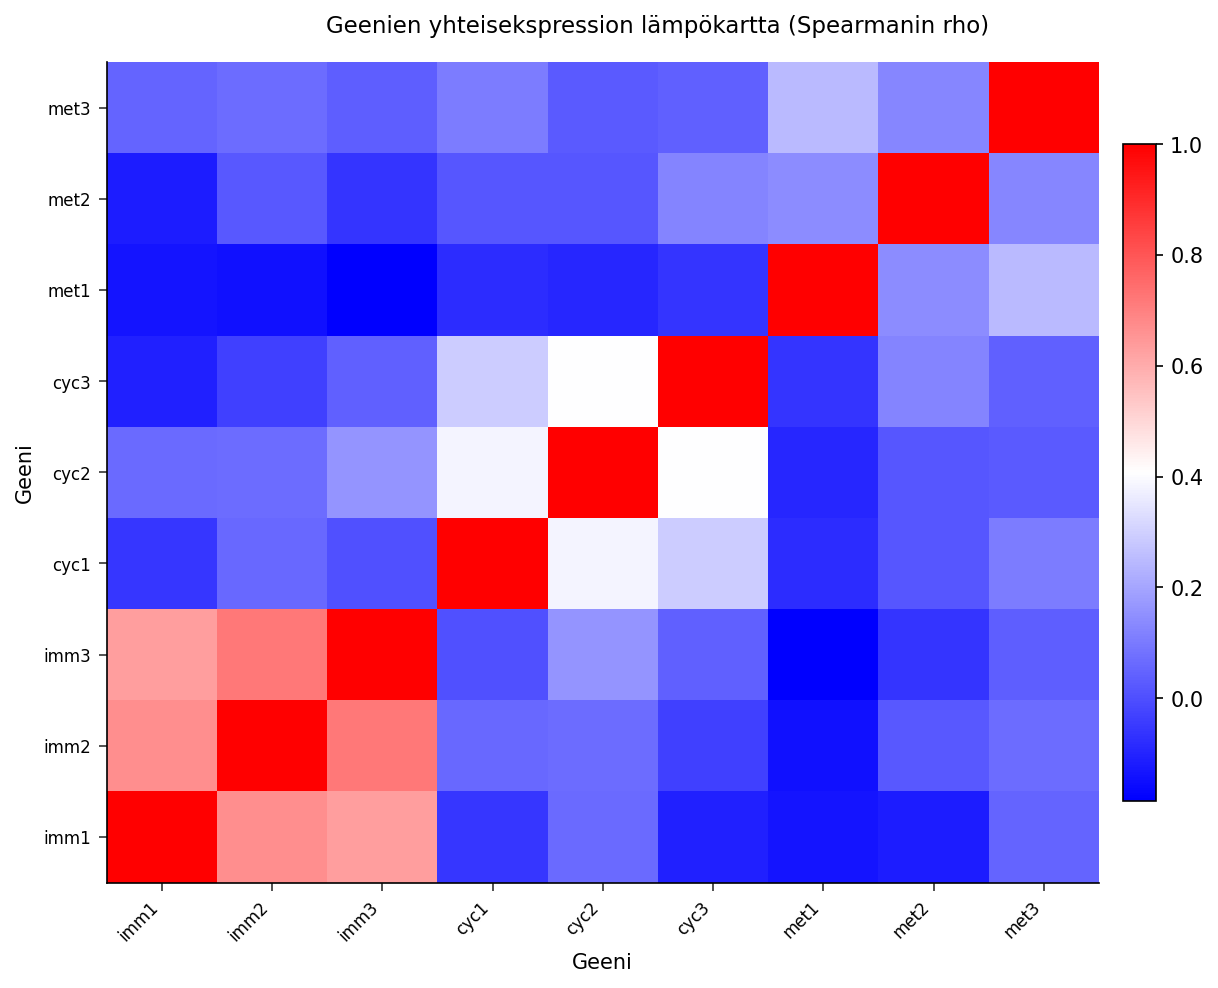

In [6]:
/* --------------------------------------------------------
   Koko 9x9 Spearman-matriisin lämpökartta. HEATMAPPARM piirtää
   kunkin geeniparin esilasketun rho-arvon; sininen-valkoinen-punainen
   -asteikko keskittää heikot parit valkoiseen ja kyllästää vahvat.
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS NIMIKE='Geeni' discreteorder=data;
    YAXIS NIMIKE='Geeni' discreteorder=data;
    OTSIKKO 'Geenien yhteisekspression lämpökartta (Spearmanin rho)';
SUORITA;
OTSIKKO;

Kolme punaista lohkoa sijaitsee lävistäjää pitkin — immuuni-, solusykli- ja metaboliset moduulit —
kun taas ympäröivät solut ovat lähes valkoisia. Immuunilohko on kylläisin,
vastaten sen korkeimpia moduulin sisäisiä korrelaatioita yllä olevassa matriisissa.

---

In [7]:
/* --------------------------------------------------------
   Verkon kaariluettelo: säilytä kukin järjestämätön geenipari
   (gene_x < gene_y), jonka |rho| ylittää kynnyksen. Nämä kaaret
   määrittävät yhteisekspressioverkon vietäväksi työkaluun kuten Cytoscape.
   -------------------------------------------------------- */
TIEDOT work.network_edges;
    ASETA work.corr_long(MISSÄ=(gene_x < gene_y));
    JOS abs(rho) >= 0.24;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.network_edges noobs label;
    MUUTTUJA gene_x gene_y mod_x mod_y rho;
    NIMIKE gene_x="Geeni X" gene_y="Geeni Y" mod_x="Moduuli X"
          mod_y="Moduuli Y" rho="Spearmanin rho";
    OTSIKKO 'Yhteisekspressioverkon kaaret (|Spearmanin rho| >= 0,24)';
SUORITA;
OTSIKKO;

/* Vie kaariluettelo ulkoista verkkovisualisointia varten */
PROSEDUURI VIE TIEDOT=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
SUORITA;

                                Yhteisekspressioverkon kaaret (|Spearmanin rho| >= 0,24)                                

Geeni X  Geeni Y  Moduuli X  Moduuli Y  Spearmanin rho
imm1     imm2     imm        imm          0.6708351085
imm1     imm3     imm        imm          0.6308427619
imm2     imm3     imm        imm          0.7179122524
cyc1     cyc2     cyc        cyc          0.3821865118
cyc1     cyc3     cyc        cyc           0.288211415
cyc2     cyc3     cyc        cyc          0.4054041891
met1     met3     met        met          0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Tulkinta

Spearman-analyysi palautti istutetun kolmen moduulin rakenteen suoraan 100
näytteestä. Alla olevat luvut on luettu PROC CORR -matriisista ja tässä muistikirjassa tuotetusta
sisäinen/välinen-yhteenvedosta:

- **Immuunimoduuli (IMM1-IMM3)** on tiiveimmin yhteisekspressoitu lohko, parittainen rho
  noin 0,63–0,72 (keskiarvo ~0,67) ja vahvin yksittäinen kaari IMM2:n ja
  IMM3:n välillä.
- **Solusyklimoduuli (CYC1-CYC3)** on kohtalaisesti yhteisekspressoitu, parittainen rho
  noin 0,29–0,41 (keskiarvo ~0,36).
- **Metabolinen moduuli (MET1-MET3)** on heikoin lohko, parittainen rho noin 0,13
  –0,25 (keskiarvo ~0,17) — yhdenmukaisesti sen pienemmän signaalilatauksen kanssa generaattorissa.
- **Moduulien väliset parit** ovat keskimäärin olennaisesti nolla (keskimääräinen rho ~-0,01, keskimääräinen |rho| ~0,07,
  suurin |rho| ~0,18), joten kolme moduulia toimivat lähes riippumattomina yhteisöinä.

Kynnystäminen tasolla |rho| >= 0,24 tuottaa yllä tulostetun verkon kaariluettelon. Jokainen säilyvä
kaari on moduulin sisäinen: kaikki kolme immuuniparia ja kaikki kolme solusykliparia ylittävät
kynnyksen, joihin liittyy vahvin metabolinen pari (MET1-MET3). Yksikään moduulien välinen pari ei
säily, joten yhteisekspressioverkko erottuu siististi kolmeksi biologiseksi
moduuliksi. Kaariluettelo viedään tiedostoon `gene_coexpression_edges.csv` visualisointia varten
ulkoisessa verkkotyökalussa, kuten Cytoscape.

Tämä käyty esimerkki näyttää PROC CORR -ydintyönkulun yhteisekspressioanalyysille: valitse
ekspressiodataan sopiva järjestyspohjainen kerroin, lue modulaarinen rakenne
korrelaatiomatriisista, kvantifioi moduulin sisäinen ja moduulien välinen voimakkuus, ja pelkistä matriisi
kynnystetyksi kaariluetteloksi verkon rakentamista varten.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Käyttövoimana <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>